# ChromVAR  
  
This is a notebook to run chromvar on peaks derived from scATAC-seq stored in a Seurat object. This can be reworked to use peaks not entered into a Seurat object. ChromVAR needs 3 inputs. 1) A count matrix that is barcode x peak or sample x peak 2) GRanges identifying peaks and 3) motifs. Motifs can be a custom set, or downloaded from JASPAR. I have code in another location to pull and save JASPAR motifs into a usable format. JASPAR seems to update yearly. The motifs I pulled are all human.  

From here there are follow-up notebooks to compare cell types and disease states.

A reference for ChromVAR can be found here: https://greenleaflab.github.io/chromVAR/articles/Introduction.html

In [1]:
#Load packages - Not sure this is cleaned up very well, maybe some unnecessary packages

suppressMessages(library(chromVAR))
suppressMessages(library(motifmatchr))
suppressMessages(library(SummarizedExperiment))

library(Signac)
library(Seurat)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(readr)
library(stringr)
library(dplyr)
set.seed(1234)

library(Matrix)
library(BiocParallel)
register(MulticoreParam(8)) ### **** THIS IS THE NUMBER OF CORES TO USE, EDIT BASED ON NEEDS

#### Send to channel code
library(parallel)

Signac built for for SeuratObject v4 was just loaded with SeuratObject
v5; disabling v5 assays and validation routines, and ensuring assays
work in strict v3/v4 compatibility mode

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘sp’


The following object is masked from ‘package:IRanges’:

    %over%



Attaching package: ‘SeuratObject’


The following object is masked from ‘package:SummarizedExperiment’:

    Assays


The following object is masked from ‘package:GenomicRanges’:

    intersect


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following object is masked from ‘package:IRanges’:

    intersect


The following object is masked from ‘package:S4Vectors’:

    intersect


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘Seurat’


The following object is masked from ‘package:SummarizedE

In [5]:
#Load in Seurat ATAC object

atac <- readRDS('/nfs/lab/projects/nPOD/clustering_files/ATAC/20230825_snATAC_finalandFixedPeaksIncl_correctedFixPeak_nPODids_noMultiomeMM426.rds')
DefaultAssay(atac) <- 'FinalFix_peaks'

atac

An object of class Seurat 
1470170 features across 174598 samples within 6 assays 
Active assay: FinalFix_peaks (385255 features, 0 variable features)
 2 layers present: counts, data
 5 other assays present: ATAC, ACTIVITY, ACTIVITY_allFeatures, Peaks_011823_final, FixPeaks_011823
 3 dimensional reductions calculated: lsi, harmony.atac, umap.atac

In [8]:
#Prep inputs for SummarizedExperiment

#Extract matrix from Seurat object
sc.data <- GetAssayData(atac,slot='data', assay="FinalFix_peaks")
sc.data.stored <- sc.data

# Extract peak locations and reformat into GRanges object
bed = str_split_fixed(rownames(sc.data), "\\-", 3) #This may need to be modified depending on your peak naming convention
bed[,1] <- paste0('chr', bed[,1])

gr= GRanges(seqnames = bed[,1], ranges = IRanges(start = as.numeric(bed[,2]), end = as.numeric(bed[,3])))

In [10]:
#Use the matrix and GRanges to make a SummarizedExperiment to put into chromvar and add metadata

fragment.counts <- SummarizedExperiment(assays=list(counts=sc.data), rowRanges=gr)
fragment.counts.stored <- fragment.counts

# Adjust to include any columns from the Seurat object metadata you will use downstream. Easier to include more now.
metrics <- select(atac[[]], orig.ident, nCount_ATAC, nFeature_ATAC, library, technology, sex,
                  condition, seurat_clusters, FinalSubtypes, frac_reads_in_peaks, TSS.enrichment) 
if (length(rownames(metrics)) == sum(rownames(colData(fragment.counts)) == rownames(metrics))) {
    print("Success adding meta data")
    colData(fragment.counts) <- cbind(colData(fragment.counts), metrics[rownames(colData(fragment.counts)),])
} else {
    print("Failed to add meta data, check column names.")
}

fragment.counts <- addGCBias(fragment.counts, genome=BSgenome.Hsapiens.UCSC.hg38)
fragment.counts

[1] "Success adding meta data"


class: RangedSummarizedExperiment 
dim: 385255 174598 
metadata(0):
assays(1): counts
rownames(385255): 1-100028699-100029199 1-100037830-100038330 ...
  X-99961904-99962404 X-99997408-99997908
rowData names(1): bias
colnames(174598): MM_339_AAACGAATCCCGAAGC-1 MM_339_AAACGAATCTATGAGC-1
  ... MM_546_GCACGGTCAGTCAGCC-1 MM_546_TTGCAGAGTTCTGAGT-1
colData names(11): orig.ident nCount_ATAC ... frac_reads_in_peaks
  TSS.enrichment

In [11]:
#Load in motifs
jaspar.motifs <- readRDS(file ='/nfs/lab/welison/multiome/chromvar/jaspar_2022_object.Rdata')
motif.ix <- matchMotifs(jaspar.motifs, fragment.counts, genome=BSgenome.Hsapiens.UCSC.hg38)

motif.ix

class: RangedSummarizedExperiment 
dim: 385255 692 
metadata(0):
assays(1): motifMatches
rownames(385255): 1-100028699-100029199 1-100037830-100038330 ...
  X-99961904-99962404 X-99997408-99997908
rowData names(1): bias
colnames(692): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA1633.2_BACH1
  MA0597.2_THAP1
colData names(1): name

In [12]:
# Create dir on first pass, place for all outputs
output_dir <- '/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/'
#dir.create(output_dir)

In [13]:
# For nPOD these motif matches were used for other analyses, but you don't need to save it for downstream chromVAR
saveRDS(assay(motif.ix), paste0(output_dir, "240209_WE_ChromVAR_Motif_Matches_Matrix.RDS"))
saveRDS(motif.ix, paste0(output_dir, "240209_WE_ChromVAR_Motif_Matches_Assay.RDS"))

In [14]:
motif.ix <- readRDS(paste0(output_dir,'240209_WE_ChromVAR_Motif_Matches_Assay.RDS'))

In [15]:
motif.ix

class: RangedSummarizedExperiment 
dim: 385255 692 
metadata(0):
assays(1): motifMatches
rownames(385255): 1-100028699-100029199 1-100037830-100038330 ...
  X-99961904-99962404 X-99997408-99997908
rowData names(1): bias
colnames(692): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA1633.2_BACH1
  MA0597.2_THAP1
colData names(1): name

In [16]:
# Run chromVAR
dev <- computeDeviations(object=fragment.counts, annotations=motif.ix)#, expectation=expected)#
head(dev)

class: chromVARDeviations 
dim: 6 174598 
metadata(0):
assays(2): deviations z
rownames(6): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA0066.1_PPARG
  MA0069.1_PAX6
rowData names(3): name fractionMatches fractionBackgroundOverlap
colnames(174598): MM_339_AAACGAATCCCGAAGC-1 MM_339_AAACGAATCTATGAGC-1
  ... MM_546_GCACGGTCAGTCAGCC-1 MM_546_TTGCAGAGTTCTGAGT-1
colData names(11): orig.ident nCount_ATAC ... frac_reads_in_peaks
  TSS.enrichment

In [17]:
saveRDS(dev, paste0(output_dir,'240209_WE_ChromVAR_Object.RDS'))

# Collect details for downstream analysis

In [18]:
# Reload chromVAR object and motifs if picking up again
in_dir <- '/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/'

dev <- readRDS(paste0(output_dir,'240209_WE_ChromVAR_Object.RDS'))
jaspar.motifs <- readRDS(file ='/nfs/lab/welison/multiome/chromvar/jaspar_2022_object.Rdata')

In [19]:
dev
jaspar.motifs

class: chromVARDeviations 
dim: 692 174598 
metadata(0):
assays(2): deviations z
rownames(692): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA1633.2_BACH1
  MA0597.2_THAP1
rowData names(3): name fractionMatches fractionBackgroundOverlap
colnames(174598): MM_339_AAACGAATCCCGAAGC-1 MM_339_AAACGAATCTATGAGC-1
  ... MM_546_GCACGGTCAGTCAGCC-1 MM_546_TTGCAGAGTTCTGAGT-1
colData names(11): orig.ident nCount_ATAC ... frac_reads_in_peaks
  TSS.enrichment

PFMatrixList of length 692
names(692): MA0030.1_FOXF2 MA0031.1_FOXD1 ... MA1633.2_BACH1 MA0597.2_THAP1

In [20]:
#This is a cell by motif deviation score (aka accessibility) matrix
devtab = deviationScores(dev)
head(devtab)

,MM_339_AAACGAATCCCGAAGC-1,MM_339_AAACGAATCTATGAGC-1,MM_339_AAACTCGGTGTGCTTA-1,MM_339_AAAGATGTCGGATGTT-1,MM_339_AAAGGATAGGAGTCTG-1,MM_339_AAAGGATAGTCGAGCA-1,MM_339_AAAGGGCCAGTCAGCC-1,MM_339_AAAGGGCTCGATATGC-1,MM_339_AAAGGGCTCGGTTAGT-1,MM_339_AAATGAGGTGCCAAGA-1,⋯,MM_391_GTGCCAGCAGGGTAAC-1,MM_460_AAATGCCGTGCATTGT-1,MM_460_GCACCTTCATGCGCTG-1,MM_460_GTAATCGCAAAGAAGG-1,MM_460_TAGTCCCAGAAAGCAG-1,MM_460_TTCATTGTCGCAAACT-1,MM_536_GGAGGATCATCCCTCA-1,MM_544_CTAGCGGGTTTAGACC-1,MM_546_GCACGGTCAGTCAGCC-1,MM_546_TTGCAGAGTTCTGAGT-1
MA0030.1_FOXF2,0.54520151,0.40990183,3.35607428,2.000801239,0.9658235,-0.459021816,0.44334913,-0.25558497,-1.6471011,0.8835954,⋯,-1.3485672,-1.24054617,0.6432168,0.53422671,-0.8512291,0.34641291,-1.3156336,-0.1606987,-0.4841276,-0.1220044
MA0031.1_FOXD1,-0.64639620,0.56733851,2.16471443,0.222432873,0.1040411,-1.840425687,1.07262678,-0.05391174,1.3205662,0.8736271,⋯,-2.0031346,-1.47942813,-0.2572786,-0.84672181,-1.4112522,-1.44849245,-1.0407649,-0.3555410,-2.0004751,-1.9848008
MA0051.1_IRF2,-0.04734576,0.21278816,-1.17043162,0.006864465,-0.6147434,0.779877039,-0.95418391,0.84427104,-0.1533793,-0.6127317,⋯,0.3081769,0.92292903,1.0573372,0.55484583,-0.8093365,1.63052376,0.6905937,-1.1745899,3.0360215,0.9012208
MA0059.1_MAX::MYC,-0.01129497,0.06407827,-0.60875582,-0.568995229,1.0334839,0.008193637,-1.30026440,-0.93085128,-2.0120367,-0.2730295,⋯,-1.1595347,0.42933240,2.3681214,-1.55277513,-1.3609323,-1.10154128,-1.9283999,-0.4375171,-0.9435472,-1.2343960
MA0066.1_PPARG,0.51365043,-0.50851101,-0.55188880,-0.488296947,-0.6396850,0.131552195,-0.30285472,1.31740292,1.8427194,0.4069058,⋯,1.3590695,0.03172931,0.1511277,0.35230581,-1.8023297,-0.83032002,0.4737512,-0.1385413,-0.9820997,-0.3458552
MA0069.1_PAX6,-2.20269142,-0.84260738,-0.01861448,0.711684614,-1.0814076,0.492742898,0.09633553,-0.41465127,-1.0573779,0.4792118,⋯,-0.5531416,1.12677198,-0.6887637,0.07516654,-1.1501492,0.08811665,-1.6427782,-0.6124164,-0.0492491,-2.0683459


In [21]:
# Variation of accessibiility across deviation scores, basically the standard errror. Null is about 1
variability <- computeVariability(dev)
head(variability)

,name,variability,bootstrap_lower_bound,bootstrap_upper_bound,p_value,p_value_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,FOXF2,1.203838,1.198981,1.208643,0.000000e+00,0.000000e+00
MA0031.1_FOXD1,FOXD1,1.258115,1.252999,1.263342,0.000000e+00,0.000000e+00
MA0051.1_IRF2,IRF2,1.113662,1.108953,1.118249,0.000000e+00,0.000000e+00
MA0059.1_MAX::MYC,MAX::MYC,1.035252,1.031647,1.038709,1.326763e-95,1.932884e-95
MA0066.1_PPARG,PPARG,1.018128,1.014559,1.021752,6.234495e-27,7.676638e-27
MA0069.1_PAX6,PAX6,1.054041,1.049918,1.058356,2.990752e-220,5.306667e-220


In [22]:
motifdata = cbind(sapply(jaspar.motifs, function(x) unlist(x@name)),sapply(jaspar.motifs, function(x) unlist(x@matrixClass )))                                                  
motifdata             #  sapply(pfm, function(x) x@tags$symbol )  ,     sapply(pfm, function(x) x@tags$family ))

MA0030.1_FOXF2,FOXF2,Fork head/winged helix factors
MA0031.1_FOXD1,FOXD1,Fork head/winged helix factors
MA0051.1_IRF2,IRF2,Tryptophan cluster factors
MA0059.1_MAX::MYC,MAX::MYC,Basic helix-loop-helix factors (bHLH)
MA0066.1_PPARG,PPARG,Nuclear receptors with C4 zinc fingers
MA0069.1_PAX6,PAX6,Paired box factors
MA0070.1_PBX1,PBX1,Homeo domain factors
MA0071.1_RORA,RORA,Nuclear receptors with C4 zinc fingers
MA0072.1_RORA,RORA,Nuclear receptors with C4 zinc fingers
MA0073.1_RREB1,RREB1,C2H2 zinc finger factors
MA0074.1_RXRA::VDR,RXRA::VDR,Nuclear receptors with C4 zinc fingers


In [25]:
#Pull in some metadata
metrics <- select(atac[[]], orig.ident, nCount_ATAC, nFeature_ATAC, library, technology, sex,
                  condition, seurat_clusters, FinalSubtypes, frac_reads_in_peaks, TSS.enrichment)


info = data.frame(def   = atac$library,
                    cells = Cells(atac),
                    groups = atac$condition_subtype,
                    cluster = atac$FinalSubtypes, samples = atac$nPOD_ID,
                    FRIP = atac$frac_reads_in_peaks, TSS.enrichment=atac$TSS.enrichment,
                    nCount_ATAC=atac$nCount_ATAC, nFeature_ATAC=atac$nFeature_ATAC)
head(info)

,def,cells,groups,cluster,samples,FRIP,TSS.enrichment,nCount_ATAC,nFeature_ATAC
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>
MM_339_AAACGAATCCCGAAGC-1,MM_339,MM_339_AAACGAATCCCGAAGC-1,earlyT1D,Acinar_1_2_6,6247,0.5421319,4.928013,748,715
MM_339_AAACGAATCTATGAGC-1,MM_339,MM_339_AAACGAATCTATGAGC-1,earlyT1D,Acinar_1_2_6,6247,0.7366399,5.622038,830,802
MM_339_AAACTCGGTGTGCTTA-1,MM_339,MM_339_AAACTCGGTGTGCTTA-1,earlyT1D,Acinar_1_2_6,6247,0.6134342,4.720066,505,489
MM_339_AAAGATGTCGGATGTT-1,MM_339,MM_339_AAAGATGTCGGATGTT-1,earlyT1D,Acinar_1_2_6,6247,0.6927803,4.036170,746,726
MM_339_AAAGGATAGGAGTCTG-1,MM_339,MM_339_AAAGGATAGGAGTCTG-1,earlyT1D,Acinar_1_2_6,6247,0.7235805,5.164169,621,602
MM_339_AAAGGATAGTCGAGCA-1,MM_339,MM_339_AAAGGATAGTCGAGCA-1,earlyT1D,Acinar_1_2_6,6247,0.5906291,4.659066,834,797


In [26]:
output_dir <- '/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/'
#dir.create(output_dir)

In [27]:
#Save devscores, motifdata, and info
write.table(devtab, file=paste0(output_dir,'devscores.txt'),quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(motifdata, file=paste0(output_dir,'motifdata.txt'),quote = FALSE, col.names = FALSE,sep='\t')
write.table(info, file=paste0(output_dir,'info_table.txt'),quote = FALSE, sep='\t')
write.table(variability, file=paste0(output_dir,'variability.txt'),quote = FALSE, col.names = TRUE, row.names = TRUE, sep='\t')
write.table(atac[[]], file=paste0(output_dir,'seurat_meta.txt'),quote = FALSE, col.names = TRUE, row.names = TRUE, sep='\t')
write.table(colData(dev), file=paste0(output_dir,'chromVAR_meta.txt'),quote = FALSE, col.names = TRUE, row.names = TRUE, sep='\t')

Variability is one of the interesting outputs and is one area to get a sense of how much change there is in the data overall

In [28]:
in_dir <- '/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/'

variability <- read.table(file=paste0(in_dir,'variability.txt'))
variability

,name,variability,bootstrap_lower_bound,bootstrap_upper_bound,p_value,p_value_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,FOXF2,1.2038381,1.1989811,1.2086428,0.000000e+00,0.000000e+00
MA0031.1_FOXD1,FOXD1,1.2581146,1.2529995,1.2633424,0.000000e+00,0.000000e+00
MA0051.1_IRF2,IRF2,1.1136617,1.1089528,1.1182487,0.000000e+00,0.000000e+00
MA0059.1_MAX::MYC,MAX::MYC,1.0352519,1.0316469,1.0387092,1.326763e-95,1.932884e-95
MA0066.1_PPARG,PPARG,1.0181275,1.0145590,1.0217521,6.234495e-27,7.676638e-27
MA0069.1_PAX6,PAX6,1.0540406,1.0499179,1.0583558,2.990752e-220,5.306667e-220
MA0070.1_PBX1,PBX1,1.1317626,1.1277974,1.1358230,0.000000e+00,0.000000e+00
MA0071.1_RORA,RORA,1.0886712,1.0847144,1.0924513,0.000000e+00,0.000000e+00
MA0072.1_RORA,RORA,1.0573873,1.0533685,1.0614821,8.290385e-248,1.490116e-247


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


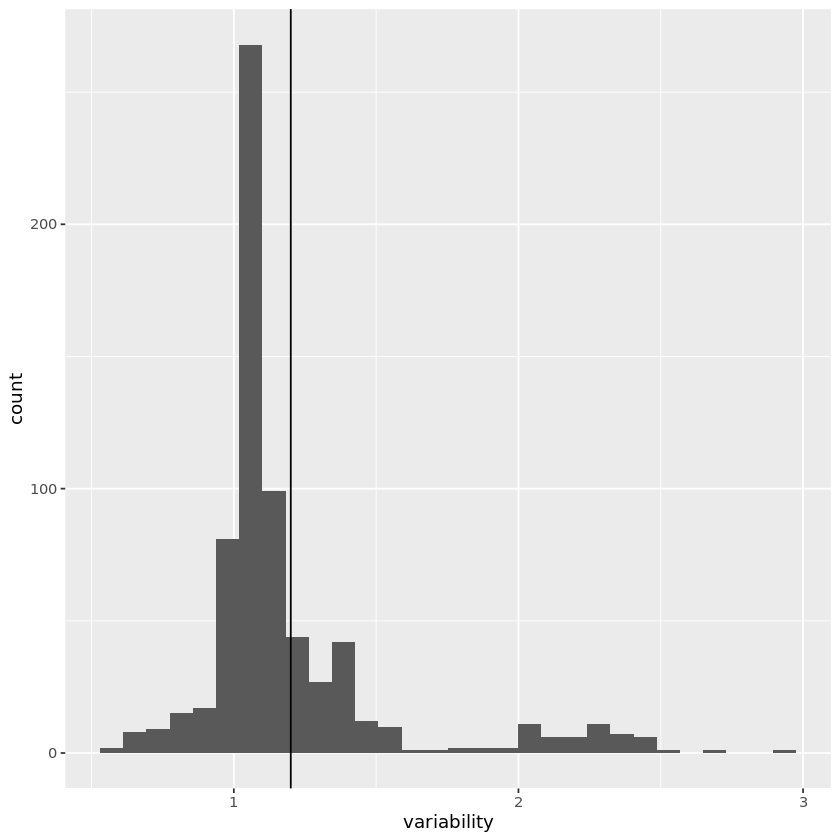

In [31]:
# Variability distirbution
ggplot(variability, aes(x=variability)) +
geom_histogram() + geom_vline(xintercept = 1.2)

In [32]:
# I often work with highly variable motifs, they in theory have some sort of difference greater than the null hypothesis
sum(variability$variability > 1.2) 
length(variability$variability > 1.2) 

[1] 178

[1] 692

In [33]:
# How many pass different cutoffs
var_filts <- c(0,.5,1,1.2,1.25,1.3,1.4,1.5,2,2.5)

print(length(variability$variability > var_filts))

for (var_filt in var_filts) {
    print(var_filt)
    print(sum(variability$variability > var_filt))
}

Warning message in variability$variability > var_filts:
“longer object length is not a multiple of shorter object length”


[1] 692
[1] 0
[1] 692
[1] 0.5
[1] 692
[1] 1
[1] 596
[1] 1.2
[1] 178
[1] 1.25
[1] 158
[1] 1.3
[1] 138
[1] 1.4
[1] 94
[1] 1.5
[1] 69
[1] 2
[1] 50
[1] 2.5
[1] 3
